# 04 - Мост в риск: масштабный VaR и стресс-матрица (Фаза 4)

То, ради чего всё затевалось: довести вейвлет-анализ до **конкретных риск-метрик**.

Три шага:
1. **Масштабный VaR/ES** - раскладываем доходность портфеля по частотным полосам
   (SWT, вариация MODWT; norm=True ⇒ сумма дисперсий полос = дисперсия ряда)
   и считаем риск на каждом горизонте отдельно.
2. **Стресс-матрица корреляций** - ковариация в стресс-окнах (Terra, FTX, USDC/SVB и др.)
   против спокойных окон; плюс **гибрид** «спокойные волы × стресс-корреляции»,
   изолирующий чистый эффект испарения диверсификации.
3. **Ранний индикатор** (опционально, честно) - опережает ли всплеск средней
   когерентности просадки портфеля.

Портфель (риск-бук, стейблы исключены): BTC 35%, ETH 25%, SOL 15%, BNB 15%, XRP 10%.
Из-за позднего листинга SOL портфельная выборка начинается с авг-2021 - COVID-эпизод
в портфельные расчёты не входит (но входит в карты Фазы 2).

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as C
from src import risk as R
from src import benchmark as B

plt.rcParams["figure.figsize"] = (11, 4.2)
plt.rcParams["axes.grid"] = True

returns = pd.read_parquet(C.PROCESSED_RETURNS)
port = R.portfolio_returns(returns)
print(f"портфель: {len(port)} дней, {port.index.min().date()} .. {port.index.max().date()}")

портфель: 1486 дней, 2020-08-12 .. 2026-06-08


## 1. Масштабно-зависимый VaR/ES

Полоса D1 - колебания с периодом 2-4 дня, D6 - 64-128 дней, S6 - тренд (>128д).

In [2]:
scale_tbl = R.scale_var_table(port)
scale_tbl.to_csv(C.RESULTS / "phase4_scale_var.csv")
scale_tbl

,periods,var_share_%,VaR95_%,ES95_%,VaR99_%,ES99_%
band,,,,,,
D1,2-4д,53.221,4.503,6.496,7.749,9.929
D2,4-8д,23.250,3.195,4.326,4.958,6.473
D3,8-16д,10.745,2.285,2.877,3.265,3.773
D4,16-32д,5.807,1.674,2.194,2.561,2.974
D5,32-64д,2.684,1.180,1.474,1.706,1.839
D6,64-128д,1.714,0.824,1.059,1.194,1.272
S6,>128д (тренд),2.579,0.710,0.931,1.138,1.160


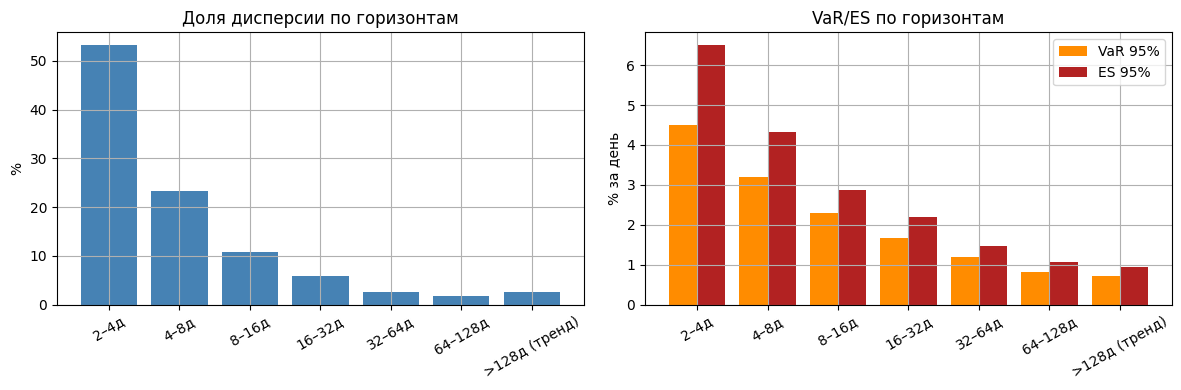

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(scale_tbl))
axes[0].bar(x, scale_tbl["var_share_%"], color="steelblue")
axes[0].set_xticks(x); axes[0].set_xticklabels(scale_tbl["periods"], rotation=30)
axes[0].set_ylabel("%"); axes[0].set_title("Доля дисперсии по горизонтам")
axes[1].bar(x - 0.2, scale_tbl["VaR95_%"], width=0.4, label="VaR 95%", color="darkorange")
axes[1].bar(x + 0.2, scale_tbl["ES95_%"], width=0.4, label="ES 95%", color="firebrick")
axes[1].set_xticks(x); axes[1].set_xticklabels(scale_tbl["periods"], rotation=30)
axes[1].set_ylabel("% за день"); axes[1].set_title("VaR/ES по горизонтам"); axes[1].legend()
fig.tight_layout(); fig.savefig(C.FIGURES / "04_scale_var.png", dpi=130)
plt.show()

**Чтение.** Больше половины дисперсии портфеля живёт в полосе 2-4 дня, и риск
монотонно убывает с горизонтом. Обычный VaR смешивает эти полосы в одно число -
а, например, для лимитов маркет-мейкинга релевантна короткая полоса, для
стратегической аллокации - длинные. Проверка Парсеваля (сумма дисперсий полос /
дисперсия ряда = 1.00) встроена в тесты.

## 2. Стресс-матрица корреляций - ключевой результат

In [4]:
var_tbl, mats = R.stress_vs_normal_table(returns)
var_tbl.round(3).to_csv(C.RESULTS / "var_es_table.csv")
var_tbl.round(3)

,vol_daily_%,VaR95_%,ES95_%,VaR99_%,ES99_%,empVaR95_%,empES95_%,empVaR99_%,empES99_%
regime,,,,,,,,,
calm,4.217,6.936,8.698,9.810,11.239,6.058,9.817,11.206,16.422
full,4.120,6.777,8.498,9.584,10.980,6.309,9.916,11.897,16.797
stress,7.776,12.791,16.040,18.090,20.725,18.064,22.112,22.752,24.247
calm_vol×stress_corr,4.876,8.020,10.057,11.342,12.994,NaN,NaN,NaN,NaN


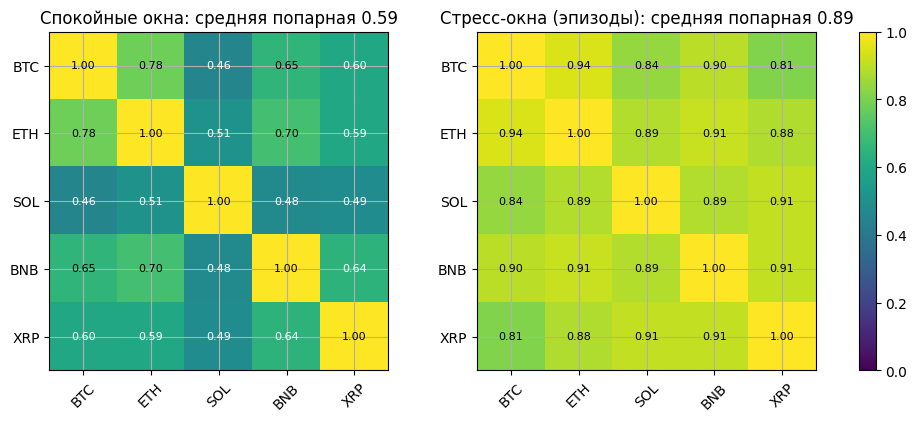

In [5]:
# Корреляционные матрицы: спокойствие vs стресс
cols = list(C.RISK.portfolio_weights)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, key, ttl in [(axes[0], "corr_calm", "Спокойные окна"),
                     (axes[1], "corr_stress", "Стресс-окна (эпизоды)")]:
    im = ax.imshow(mats[key], vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(range(5)); ax.set_xticklabels(cols, rotation=45)
    ax.set_yticks(range(5)); ax.set_yticklabels(cols)
    mean_od = mats[key].values[np.triu_indices(5, 1)].mean()
    ax.set_title(f"{ttl}: средняя попарная {mean_od:.2f}")
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f"{mats[key].values[i,j]:.2f}", ha="center", va="center",
                    color="white" if mats[key].values[i,j] < 0.65 else "black", fontsize=8)
fig.colorbar(im, ax=axes, fraction=0.03)
fig.savefig(C.FIGURES / "04_corr_calm_vs_stress.png", dpi=130, bbox_inches="tight")
plt.show()

In [6]:
# Главные числа для README
para = var_tbl["VaR95_%"]
print(f"VaR95 (параметрический, дневной):")
print(f"  спокойный режим : {para['calm']:.2f}%")
print(f"  стрессовый режим: {para['stress']:.2f}%  (x{para['stress']/para['calm']:.2f})")
print(f"  гибрид (спокойные волы, стресс-корреляции): {para['calm_vol×stress_corr']:.2f}%"
      f"  (+{100*(para['calm_vol×stress_corr']/para['calm']-1):.0f}% чисто от корреляций)")

VaR95 (параметрический, дневной):
  спокойный режим : 6.94%
  стрессовый режим: 12.79%  (x1.84)
  гибрид (спокойные волы, стресс-корреляции): 8.02%  (+16% чисто от корреляций)


**Чтение таблицы.**
- `stress` против `calm`: дневной VaR95 почти удваивается - но тут смешаны два
  эффекта (волы выросли И корреляции выросли).
- Строка `calm_vol×stress_corr` отвечает на чистый вопрос риск-менеджера:
  «что будет с риском книги, если волатильности останутся прежними, а
  **диверсификация испарится** так, как она реально испаряется в кризис?»
  Ответ: VaR растёт на ~16% *только* из-за сдвига корреляций 0.59 → 0.89.
- Эмпирические квантили в стрессе выше параметрических - тяжёлые хвосты;
  нормальное приближение в кризис занижает риск (честно фиксируем).
- Оговорка: стресс-выборка ~60-70 дней на 5 активов - ковариация оценена шумно;
  это цена событийного определения стресса, отражена в Ограничениях.

## 3. Ранний индикатор (честная проверка)

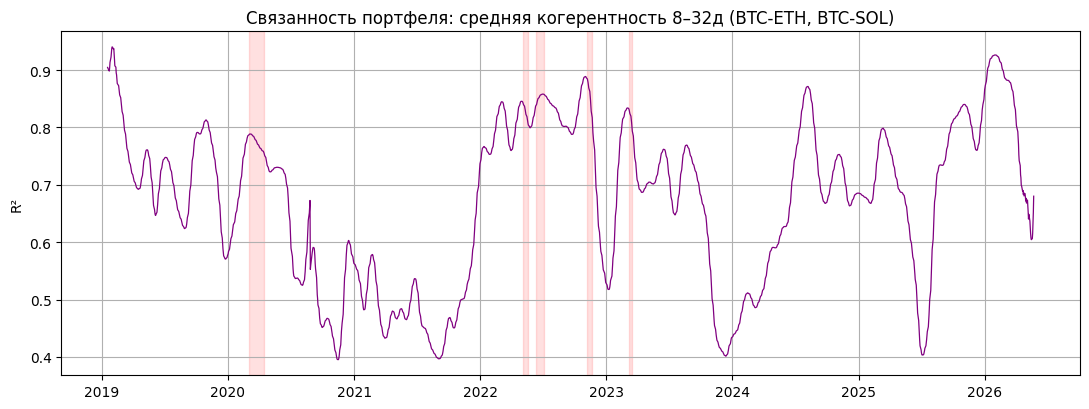

{'n_alarm_days': 324, 'hit_rate': 0.259, 'base_rate': 0.11, 'lift': 2.362, 'horizon_days': 20}


In [7]:
signal = R.connectedness_signal(returns)          # средняя когерентность 8-32д, BTC-ETH/BTC-SOL
check = R.indicator_check(signal, port)
fig, ax = plt.subplots()
ax.plot(signal.index, signal.values, lw=0.9, color="purple")
B.shade_episodes(ax)
ax.set_title("Связанность портфеля: средняя когерентность 8-32д (BTC-ETH, BTC-SOL)")
ax.set_ylabel("R²")
fig.tight_layout(); fig.savefig(C.FIGURES / "04_connectedness.png", dpi=130)
plt.show()
print({k: (round(v, 3) if isinstance(v, float) else v) for k, v in check.items()})

In [8]:
import json
pd.Series(check).to_csv(C.RESULTS / "phase4_indicator_check.csv")
hit, base, lift = check["hit_rate"], check["base_rate"], check["lift"]
if np.isnan(hit):
    verdict = "сигналов слишком мало - индикатор не оценивается"
elif lift > 1.3:
    verdict = f"всплеск связанности умеренно информативен: P(просадка|сигнал)={hit:.0%} vs базовые {base:.0%} (lift {lift:.2f})"
elif lift > 1.0:
    verdict = f"эффект слабый: {hit:.0%} vs {base:.0%} (lift {lift:.2f}) - на торговый сигнал не тянет"
else:
    verdict = f"опережающей силы нет: {hit:.0%} vs {base:.0%} (lift {lift:.2f})"
print("Вердикт:", verdict)

Вердикт: всплеск связанности умеренно информативен: P(просадка|сигнал)=26% vs базовые 11% (lift 2.36)


**Принцип честности.** Конфигурация индикатора одна, выбрана заранее
(квантиль 85%, горизонт 20д), без перебора параметров. Какой результат вышел -
такой и публикуем; «не работает» - тоже результат, и для риск-команды он
информативнее натянутого бэктеста.

## Вывод Фазы 4

1. Риск портфеля сосредоточен в коротких полосах (53% дисперсии в 2-4д), убывает
   с горизонтом - обычный VaR эту структуру стирает.
2. **Стресс-матрица**: корреляции 0.59 → 0.89; даже при неизменных волатильностях
   это +16% к VaR - количественная цена «испарившейся диверсификации».
   Полный стресс-режим (волы + корреляции) почти удваивает дневной VaR95.
3. Эмпирика в стрессе тяжелее нормали - параметрические числа в кризис занижают
   риск; в таблице приведены оба ряда оценок.
4. Финальная таблица - `results/var_es_table.csv`.